# Analiza profili zawodników piłkarskich

**Zbiór danych:**  
https://www.kaggle.com/datasets/hubertsidorowicz/football-players-stats-2024-2025


### H1
Zawodnicy występujący na różnych pozycjach różnią się profilem statystyk meczowych: obrońcy osiągają wyższą liczbę odbiorów i przechwytów na 90 minut, napastnicy wyższą liczbę goli i asyst na 90 minut, natomiast pomocnicy wyższą liczbę progresywnych podań na 90 minut.

- zmienna zależna: pozycja zawodnika
- zmienne objaśniające: `Tkl+Int/90`, `G+A/90`, `PrgP/90`

### H2
Liczba goli zawodnika na 90 minut rośnie wraz ze wzrostem wartości oczekiwanych goli, liczby strzałów oraz liczby strzałów celnych na 90 minut.

- zmienna zależna: `Gls/90`
- zmienne objaśniające: `xG/90`, `Sh/90`, `SoT/90`

### H3
Liczba progresywnych podań zawodnika na 90 minut rośnie wraz z liczbą kontaktów z piłką, kluczowych podań oraz prowadzeń piłki na 90 minut.

- zmienna zależna: `PrgP/90`
- zmienne objaśniające: `Touches/90`, `KP/90`, `Carries/90`

In [1]:
from pathlib import Path
import os
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import chi2_contingency, kruskal, pearsonr, spearmanr, shapiro
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.mixture import GaussianMixture
from sklearn.model_selection import KFold, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import (
    DecisionTreeClassifier, DecisionTreeRegressor,
    export_text, plot_tree
)
from sklearn.metrics import (
    accuracy_score, classification_report,
    ConfusionMatrixDisplay, mean_absolute_error,
    mean_squared_error, r2_score, silhouette_score
)

RANDOM_STATE = 42
MIN_MINUTES = 450
CSV_PATH = "players_data_light-2024_2025.csv"

OUTPUT_DIR = Path("wyniki")
OUTPUT_DIR.mkdir(exist_ok=True)

## Wczytanie i przygotowanie danych

In [2]:
df = pd.read_csv(CSV_PATH)

required_columns = [
    "Player", "Pos", "Squad", "Comp", "Min", "90s",
    "Gls", "G+A", "xG", "Sh", "SoT",
    "Tkl+Int", "PrgP", "Touches", "KP", "Carries"
]

missing_columns = [col for col in required_columns if col not in df.columns]
if missing_columns:
    raise ValueError(f"Brakuje kolumn: {missing_columns}")

print("Liczba rekordów:", len(df))
df[required_columns].head()

Liczba rekordów: 2854


,Player,Pos,Squad,Comp,Min,90s,Gls,G+A,xG,Sh,SoT,Tkl+Int,PrgP,Touches,KP,Carries
0,Max Aarons,DF,Bournemouth,eng Premier League,86,1.0,0,0,0.0,0,0,3,8,73,0,41
1,Max Aarons,"DF,MF",Valencia,es La Liga,120,1.3,0,0,0.0,0,0,4,6,85,1,46
2,Rodrigo Abajas,DF,Valencia,es La Liga,65,0.7,0,0,0.1,1,0,4,2,36,0,13
3,James Abankwah,"DF,MF",Udinese,it Serie A,88,1.0,0,0,0.1,1,0,5,4,65,0,29
4,Keyliane Abdallah,FW,Marseille,fr Ligue 1,3,0.0,0,0,0.0,0,0,1,0,4,0,1


In [3]:
data = df[required_columns].copy()

numeric_columns = [
    "Min", "90s", "Gls", "G+A", "xG", "Sh", "SoT",
    "Tkl+Int", "PrgP", "Touches", "KP", "Carries"
]

for col in numeric_columns:
    data[col] = pd.to_numeric(
        data[col].astype(str).str.replace(",", "", regex=False),
        errors="coerce"
    )

data["position"] = data["Pos"].astype(str).str.split(",").str[0].str.strip()
data = data[
    data["position"].isin(["DF", "MF", "FW"]) &
    (data["Min"] >= MIN_MINUTES) &
    (data["90s"] > 0)
].copy()

per90_columns = {
    "Gls": "gls_per90",
    "G+A": "ga_per90",
    "xG": "xg_per90",
    "Sh": "sh_per90",
    "SoT": "sot_per90",
    "Tkl+Int": "tkl_int_per90",
    "PrgP": "prgp_per90",
    "Touches": "touches_per90",
    "KP": "kp_per90",
    "Carries": "carries_per90"
}

for source, target in per90_columns.items():
    data[target] = data[source] / data["90s"]

H1_FEATURES = ["tkl_int_per90", "ga_per90", "prgp_per90"]
H2_TARGET = "gls_per90"
H2_FEATURES = ["xg_per90", "sh_per90", "sot_per90"]
H3_TARGET = "prgp_per90"
H3_FEATURES = ["touches_per90", "kp_per90", "carries_per90"]

ALL_NUMERIC = list(dict.fromkeys(
    H1_FEATURES + [H2_TARGET] + H2_FEATURES + H3_FEATURES
))

data = data.dropna(subset=ALL_NUMERIC + ["position"]).copy()

print("Liczba zawodników po czyszczeniu:", len(data))
data[["Player", "position", "Squad", "Comp", "Min"] + ALL_NUMERIC].head()

Liczba zawodników po czyszczeniu: 1827


,Player,position,Squad,Comp,Min,tkl_int_per90,ga_per90,prgp_per90,gls_per90,xg_per90,sh_per90,sot_per90,touches_per90,kp_per90,carries_per90
5,Yunis Abdelhamid,DF,Saint-Étienne,fr Ligue 1,1033,2.695652,0.000000,1.913043,0.000000,0.017391,0.173913,0.086957,55.739130,0.173913,28.000000
6,Himad Abdelli,MF,Angers,fr Ligue 1,2842,2.341772,0.221519,6.550633,0.189873,0.202532,1.107595,0.253165,63.069620,1.234177,37.436709
7,Mohamed Abdelmoneim,DF,Nice,fr Ligue 1,855,3.789474,0.000000,5.473684,0.000000,0.000000,0.000000,0.000000,66.842105,0.000000,36.000000
8,Ali Abdi,DF,Nice,fr Ligue 1,1393,4.064516,0.451613,2.709677,0.322581,0.277419,1.870968,0.709677,57.161290,1.290323,25.225806
10,Abel,DF,Osasuna,es La Liga,2074,3.434783,0.086957,3.347826,0.086957,0.021739,0.521739,0.173913,57.478261,0.695652,26.304348


## Statystyki opisowe

In [4]:
def first_mode(series):
    mode = series.mode()
    return mode.iloc[0] if len(mode) else np.nan

stats = pd.DataFrame({
    "liczba": data[ALL_NUMERIC].count(),
    "średnia": data[ALL_NUMERIC].mean(),
    "mediana": data[ALL_NUMERIC].median(),
    "moda": data[ALL_NUMERIC].apply(first_mode),
    "minimum": data[ALL_NUMERIC].min(),
    "maksimum": data[ALL_NUMERIC].max(),
    "odchylenie_std": data[ALL_NUMERIC].std(),
    "wariancja": data[ALL_NUMERIC].var()
}).round(3)

stats.to_csv(OUTPUT_DIR / "statystyki_opisowe.csv")
stats

,liczba,średnia,mediana,moda,minimum,maksimum,odchylenie_std,wariancja
tkl_int_per90,1827,2.462,2.428,2.500,0.156,7.031,1.090,1.188
ga_per90,1827,0.233,0.163,0.000,0.000,1.491,0.230,0.053
prgp_per90,1827,3.620,3.354,3.333,0.412,11.456,1.721,2.962
gls_per90,1827,0.137,0.079,0.000,0.000,1.149,0.172,0.029
xg_per90,1827,0.142,0.079,0.000,0.000,1.153,0.154,0.024
sh_per90,1827,1.254,0.962,0.000,0.000,5.000,0.925,0.855
sot_per90,1827,0.422,0.287,0.000,0.000,2.552,0.395,0.156
touches_per90,1827,55.537,55.377,45.000,18.662,122.373,16.121,259.875
kp_per90,1827,0.934,0.826,0.000,0.000,3.547,0.648,0.420
carries_per90,1827,30.738,29.302,20.000,8.000,77.357,10.633,113.068


In [5]:
position_counts = data["position"].value_counts()
league_counts = data["Comp"].value_counts()
position_league = pd.crosstab(data["position"], data["Comp"])

print("Liczność pozycji:")
display(position_counts)

print("Liczność lig:")
display(league_counts)

print("Pozycja x liga:")
display(position_league)

position_counts.to_csv(OUTPUT_DIR / "licznosc_pozycji.csv")
league_counts.to_csv(OUTPUT_DIR / "licznosc_lig.csv")
position_league.to_csv(OUTPUT_DIR / "tabela_pozycja_liga.csv")

Liczność pozycji:


position
DF    761
MF    609
FW    457
Name: count, dtype: int64

Liczność lig:


Comp
es La Liga            399
it Serie A            396
eng Premier League    367
fr Ligue 1            344
de Bundesliga         321
Name: count, dtype: int64

Pozycja x liga:


Comp,de Bundesliga,eng Premier League,es La Liga,fr Ligue 1,it Serie A
position,,,,,
DF,140,149,155,147,170
FW,75,99,102,85,96
MF,106,119,142,112,130


## Wykresy i korelacje

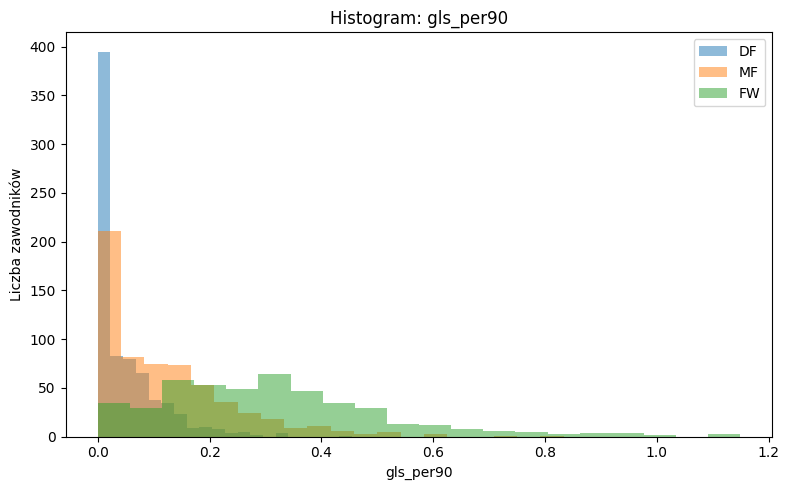

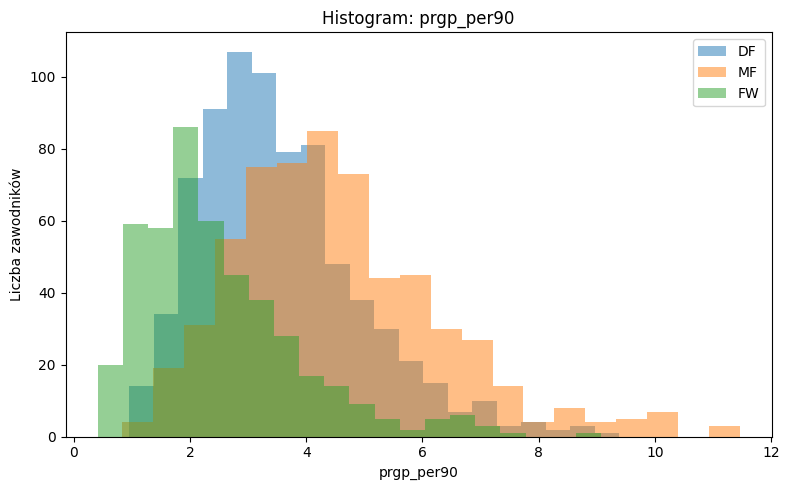

,tkl_int_per90,ga_per90,prgp_per90
position,,,
DF,2.821,0.100,3.549
MF,2.814,0.226,4.546
FW,1.395,0.462,2.506


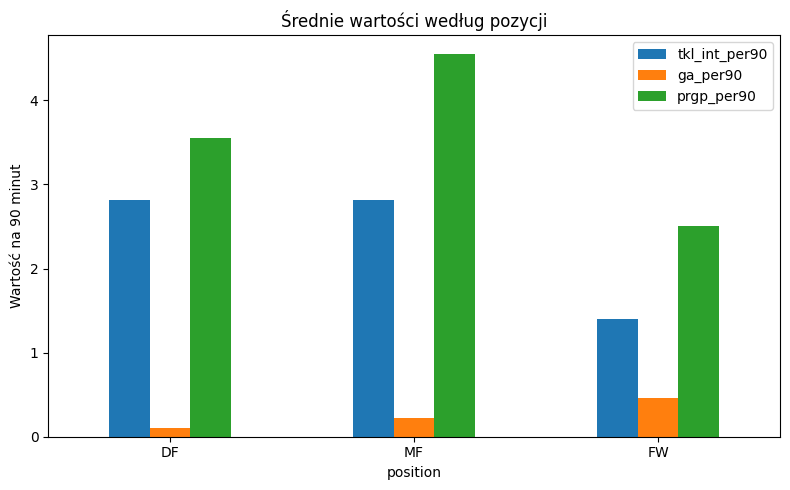

In [6]:
for variable in [H2_TARGET, H3_TARGET]:
    plt.figure(figsize=(8, 5))
    for position in ["DF", "MF", "FW"]:
        values = data.loc[data["position"] == position, variable]
        plt.hist(values, bins=20, alpha=0.5, label=position)
    plt.title(f"Histogram: {variable}")
    plt.xlabel(variable)
    plt.ylabel("Liczba zawodników")
    plt.legend()
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / f"histogram_{variable}.png", dpi=150)
    plt.show()

means_h1 = data.groupby("position")[H1_FEATURES].mean().reindex(["DF", "MF", "FW"])
display(means_h1.round(3))

means_h1.plot(kind="bar", figsize=(8, 5))
plt.title("Średnie wartości według pozycji")
plt.ylabel("Wartość na 90 minut")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "srednie_wedlug_pozycji.png", dpi=150)
plt.show()

In [7]:
corr = data[ALL_NUMERIC].corr().round(2)
corr.to_csv(OUTPUT_DIR / "macierz_korelacji.csv")
corr

,tkl_int_per90,ga_per90,prgp_per90,gls_per90,xg_per90,sh_per90,sot_per90,touches_per90,kp_per90,carries_per90
tkl_int_per90,1.00,-0.47,0.27,-0.51,-0.56,-0.52,-0.53,0.44,-0.22,0.24
ga_per90,-0.47,1.00,-0.04,0.90,0.82,0.77,0.81,-0.37,0.55,-0.22
prgp_per90,0.27,-0.04,1.00,-0.17,-0.23,-0.14,-0.17,0.70,0.33,0.70
gls_per90,-0.51,0.90,-0.17,1.00,0.87,0.76,0.83,-0.44,0.34,-0.29
xg_per90,-0.56,0.82,-0.23,0.87,1.00,0.85,0.87,-0.52,0.35,-0.36
sh_per90,-0.52,0.77,-0.14,0.76,0.85,1.00,0.92,-0.49,0.51,-0.31
sot_per90,-0.53,0.81,-0.17,0.83,0.87,0.92,1.00,-0.48,0.45,-0.31
touches_per90,0.44,-0.37,0.70,-0.44,-0.52,-0.49,-0.48,1.00,-0.06,0.92
kp_per90,-0.22,0.55,0.33,0.34,0.35,0.51,0.45,-0.06,1.00,0.03
carries_per90,0.24,-0.22,0.70,-0.29,-0.36,-0.31,-0.31,0.92,0.03,1.00


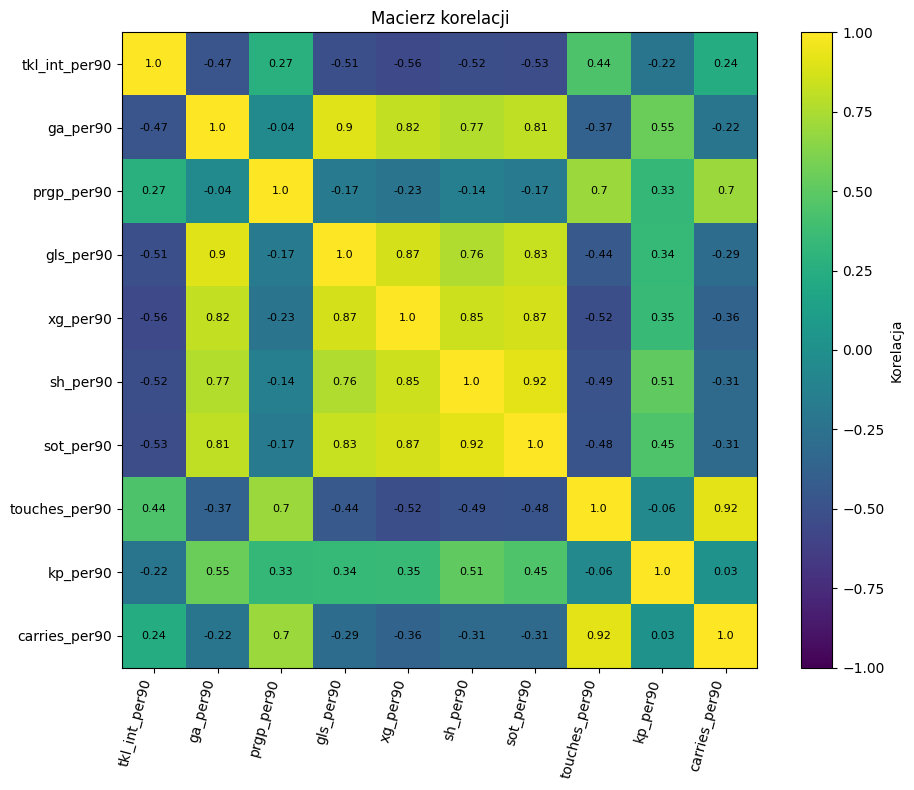

In [8]:
plt.figure(figsize=(10, 8))
plt.imshow(corr, vmin=-1, vmax=1)
plt.colorbar(label="Korelacja")
plt.xticks(range(len(corr.columns)), corr.columns, rotation=75, ha="right")
plt.yticks(range(len(corr.index)), corr.index)

for i in range(len(corr.index)):
    for j in range(len(corr.columns)):
        plt.text(j, i, corr.iloc[i, j], ha="center", va="center", fontsize=8)

plt.title("Macierz korelacji")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "macierz_korelacji.png", dpi=150)
plt.show()

## Test Chi-kwadrat

In [9]:
def chi_square_result(feature):
    temp = data[[feature, "position"]].copy()
    temp["przedzial"] = pd.qcut(temp[feature], q=4, duplicates="drop")
    table = pd.crosstab(temp["position"], temp["przedzial"])
    chi2, p_value, dof, _ = chi2_contingency(table)
    return {
        "zmienna": feature,
        "chi2": chi2,
        "p_value": p_value,
        "stopnie_swobody": dof
    }

chi2_results = pd.DataFrame([
    chi_square_result(feature) for feature in ALL_NUMERIC
]).sort_values("chi2", ascending=False)

chi2_results.to_csv(OUTPUT_DIR / "chi2.csv", index=False)
chi2_results.round(4)

,zmienna,chi2,p_value,stopnie_swobody
5,sh_per90,1266.5395,0.0,6
4,xg_per90,1111.7578,0.0,6
6,sot_per90,1102.4825,0.0,6
7,touches_per90,904.0414,0.0,6
3,gls_per90,769.8522,0.0,4
1,ga_per90,751.2793,0.0,6
0,tkl_int_per90,701.9166,0.0,6
8,kp_per90,528.6186,0.0,6
2,prgp_per90,447.0339,0.0,6
9,carries_per90,409.4571,0.0,6


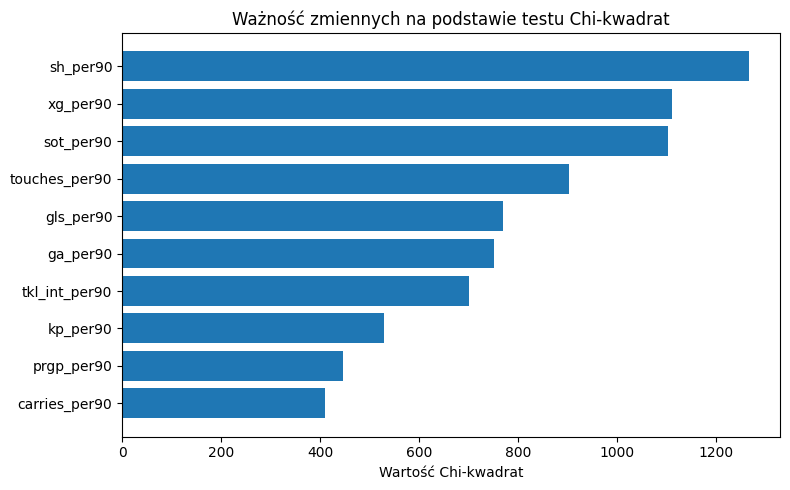

In [10]:
plt.figure(figsize=(8, 5))
plt.barh(chi2_results["zmienna"][::-1], chi2_results["chi2"][::-1])
plt.title("Ważność zmiennych na podstawie testu Chi-kwadrat")
plt.xlabel("Wartość Chi-kwadrat")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "chi2_waznosc.png", dpi=150)
plt.show()

## Normalność, wartości odstające i wykresy ramka-wąsy

In [11]:
normality_rows = []

for col in ALL_NUMERIC:
    series = data[col].dropna()
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    outliers = ((series < lower) | (series > upper)).sum()

    sample = series.sample(min(len(series), 5000), random_state=RANDOM_STATE)
    _, p_value = shapiro(sample)

    normality_rows.append({
        "zmienna": col,
        "liczba_odstajacych": outliers,
        "shapiro_p_value": p_value,
        "rozkład_normalny_alpha_0_05": p_value >= 0.05
    })

normality = pd.DataFrame(normality_rows)
normality.to_csv(OUTPUT_DIR / "normalnosc_i_odstajace.csv", index=False)
normality.round(4)

,zmienna,liczba_odstajacych,shapiro_p_value,rozkład_normalny_alpha_0_05
0,tkl_int_per90,10,0.0,False
1,ga_per90,51,0.0,False
2,prgp_per90,42,0.0,False
3,gls_per90,78,0.0,False
4,xg_per90,99,0.0,False
5,sh_per90,16,0.0,False
6,sot_per90,34,0.0,False
7,touches_per90,17,0.0,False
8,kp_per90,22,0.0,False
9,carries_per90,41,0.0,False


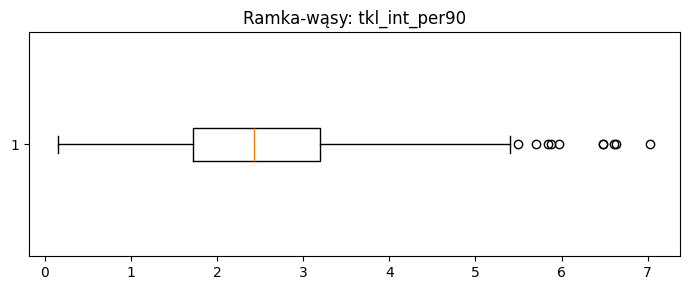

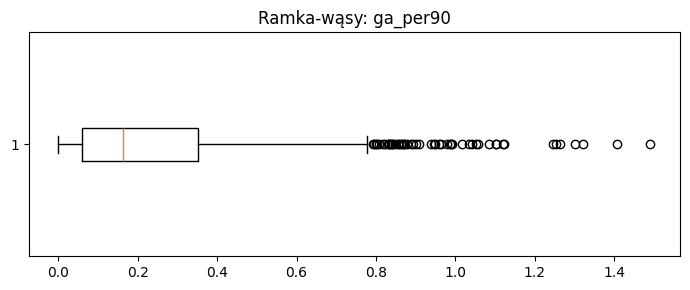

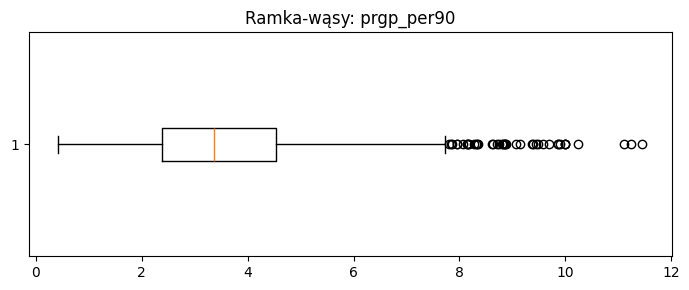

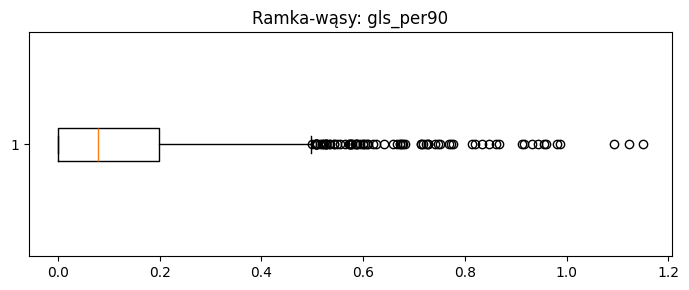

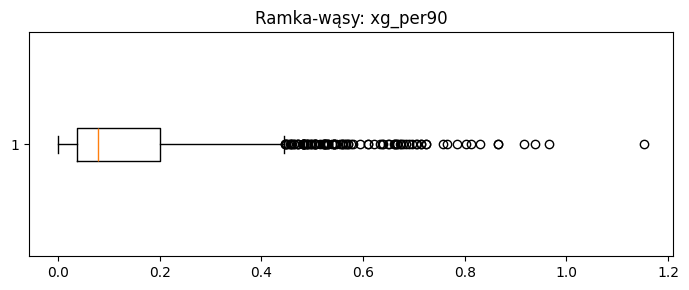

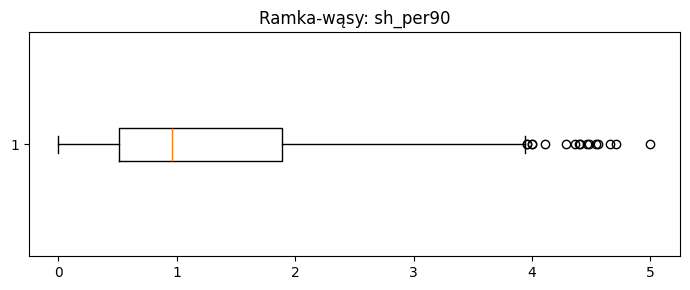

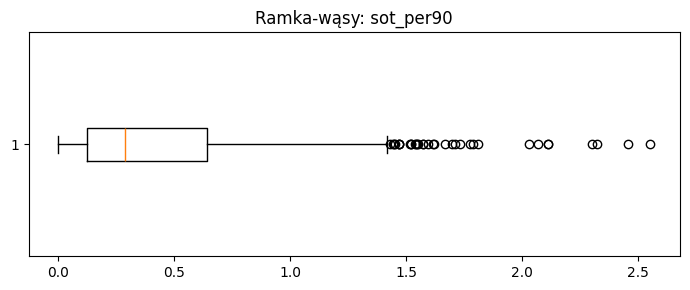

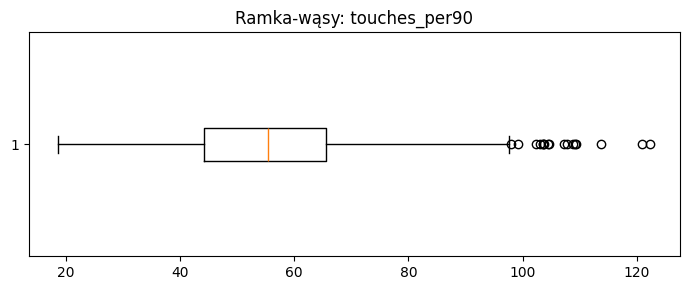

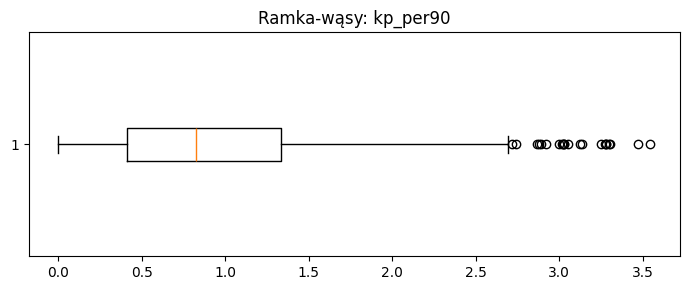

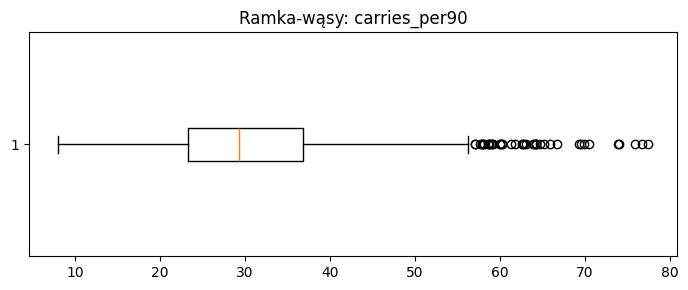

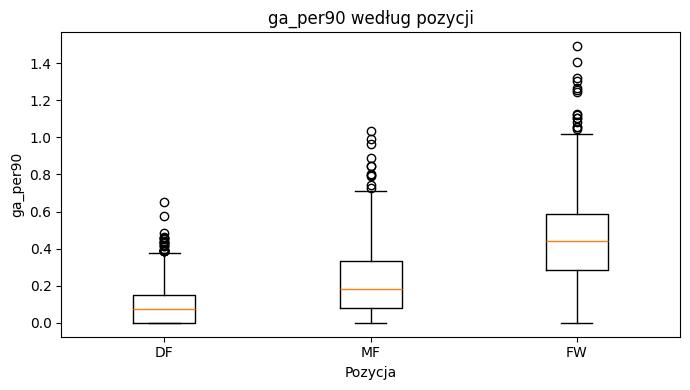

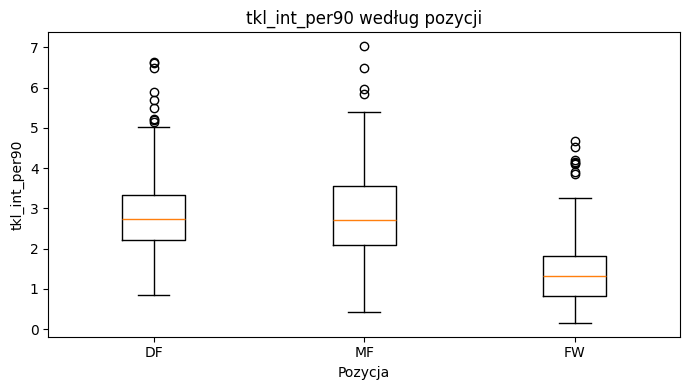

In [12]:
for col in ALL_NUMERIC:
    plt.figure(figsize=(7, 3))
    plt.boxplot(data[col].dropna(), vert=False)
    plt.title(f"Ramka-wąsy: {col}")
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / f"boxplot_{col}.png", dpi=120)
    plt.show()

for col in ["ga_per90", "tkl_int_per90"]:
    groups = [
        data.loc[data["position"] == position, col].dropna()
        for position in ["DF", "MF", "FW"]
    ]
    plt.figure(figsize=(7, 4))
    plt.boxplot(groups, tick_labels=["DF", "MF", "FW"])
    plt.title(f"{col} według pozycji")
    plt.xlabel("Pozycja")
    plt.ylabel(col)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / f"boxplot_{col}_wedlug_pozycji.png", dpi=150)
    plt.show()

## Wykresy rozrzutu

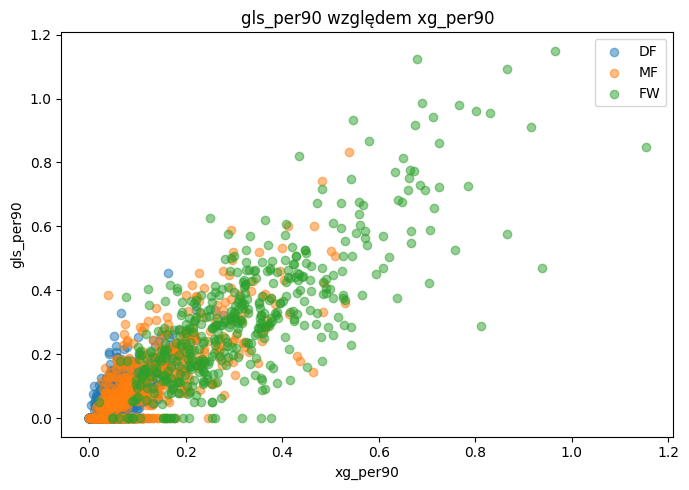

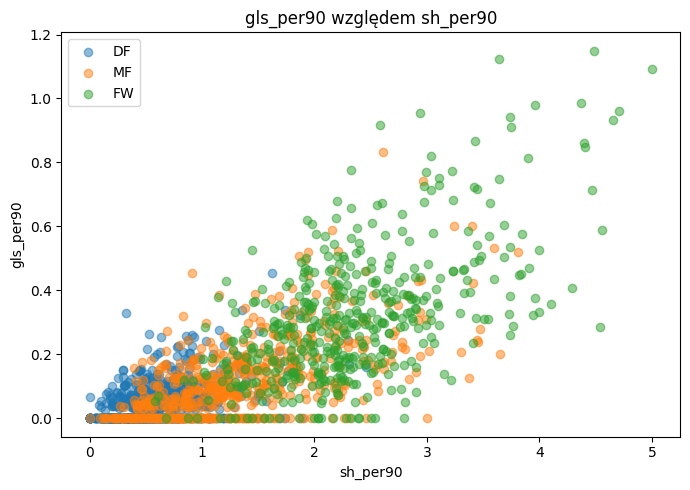

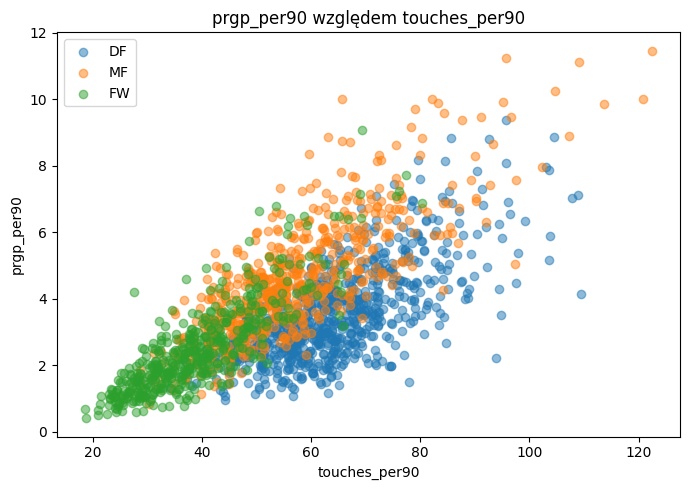

In [13]:
scatter_pairs = [
    ("xg_per90", "gls_per90"),
    ("sh_per90", "gls_per90"),
    ("touches_per90", "prgp_per90")
]

for x_col, y_col in scatter_pairs:
    plt.figure(figsize=(7, 5))
    for position in ["DF", "MF", "FW"]:
        subset = data[data["position"] == position]
        plt.scatter(subset[x_col], subset[y_col], alpha=0.5, label=position)
    plt.title(f"{y_col} względem {x_col}")
    plt.xlabel(x_col)
    plt.ylabel(y_col)
    plt.legend()
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / f"scatter_{y_col}_vs_{x_col}.png", dpi=150)
    plt.show()

## Weryfikacja hipotez

In [14]:
h1_rows = []

for feature in H1_FEATURES:
    groups = [
        data.loc[data["position"] == position, feature]
        for position in ["DF", "MF", "FW"]
    ]
    statistic, p_value = kruskal(*groups)
    means = data.groupby("position")[feature].mean()

    h1_rows.append({
        "zmienna": feature,
        "średnia_DF": means.get("DF"),
        "średnia_MF": means.get("MF"),
        "średnia_FW": means.get("FW"),
        "p_value": p_value,
        "istotna_roznica": p_value < 0.05
    })

h1_results = pd.DataFrame(h1_rows)
h1_results.to_csv(OUTPUT_DIR / "H1_wyniki.csv", index=False)
h1_results.round(4)

,zmienna,średnia_DF,średnia_MF,średnia_FW,p_value,istotna_roznica
0,tkl_int_per90,2.8211,2.8145,1.3953,0.0,True
1,ga_per90,0.1004,0.2261,0.4619,0.0,True
2,prgp_per90,3.5490,4.5463,2.5057,0.0,True


In [15]:
def correlation_results(target, features):
    rows = []
    for feature in features:
        pearson_r, pearson_p = pearsonr(data[feature], data[target])
        spearman_r, spearman_p = spearmanr(data[feature], data[target])

        rows.append({
            "zmienna_zalezna": target,
            "predyktor": feature,
            "pearson_r": pearson_r,
            "pearson_p": pearson_p,
            "spearman_r": spearman_r,
            "spearman_p": spearman_p
        })
    return pd.DataFrame(rows)

h2_results = correlation_results(H2_TARGET, H2_FEATURES)
h3_results = correlation_results(H3_TARGET, H3_FEATURES)

print("H2")
display(h2_results.round(4))

print("H3")
display(h3_results.round(4))

h2_results.to_csv(OUTPUT_DIR / "H2_wyniki.csv", index=False)
h3_results.to_csv(OUTPUT_DIR / "H3_wyniki.csv", index=False)

H2


,zmienna_zalezna,predyktor,pearson_r,pearson_p,spearman_r,spearman_p
0,gls_per90,xg_per90,0.8741,0.0,0.8254,0.0
1,gls_per90,sh_per90,0.7649,0.0,0.7418,0.0
2,gls_per90,sot_per90,0.8346,0.0,0.8078,0.0


H3


,zmienna_zalezna,predyktor,pearson_r,pearson_p,spearman_r,spearman_p
0,prgp_per90,touches_per90,0.7029,0.0,0.6773,0.0
1,prgp_per90,kp_per90,0.3297,0.0,0.2569,0.0
2,prgp_per90,carries_per90,0.7035,0.0,0.6870,0.0


## Drzewa decyzyjne

Accuracy: 0.641
              precision    recall  f1-score   support

          DF       0.64      0.80      0.71       191
          FW       0.78      0.71      0.74       114
          MF       0.52      0.39      0.45       152

    accuracy                           0.64       457
   macro avg       0.65      0.63      0.63       457
weighted avg       0.63      0.64      0.63       457



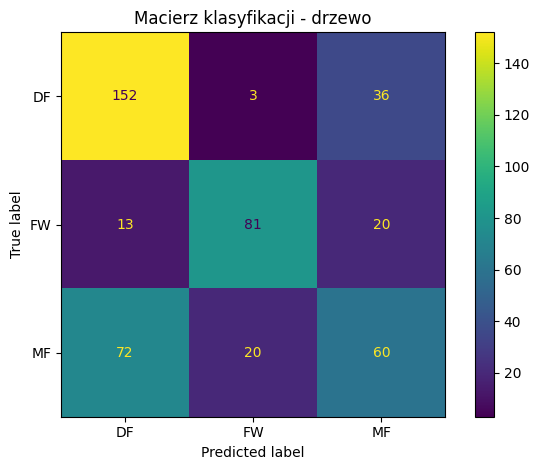

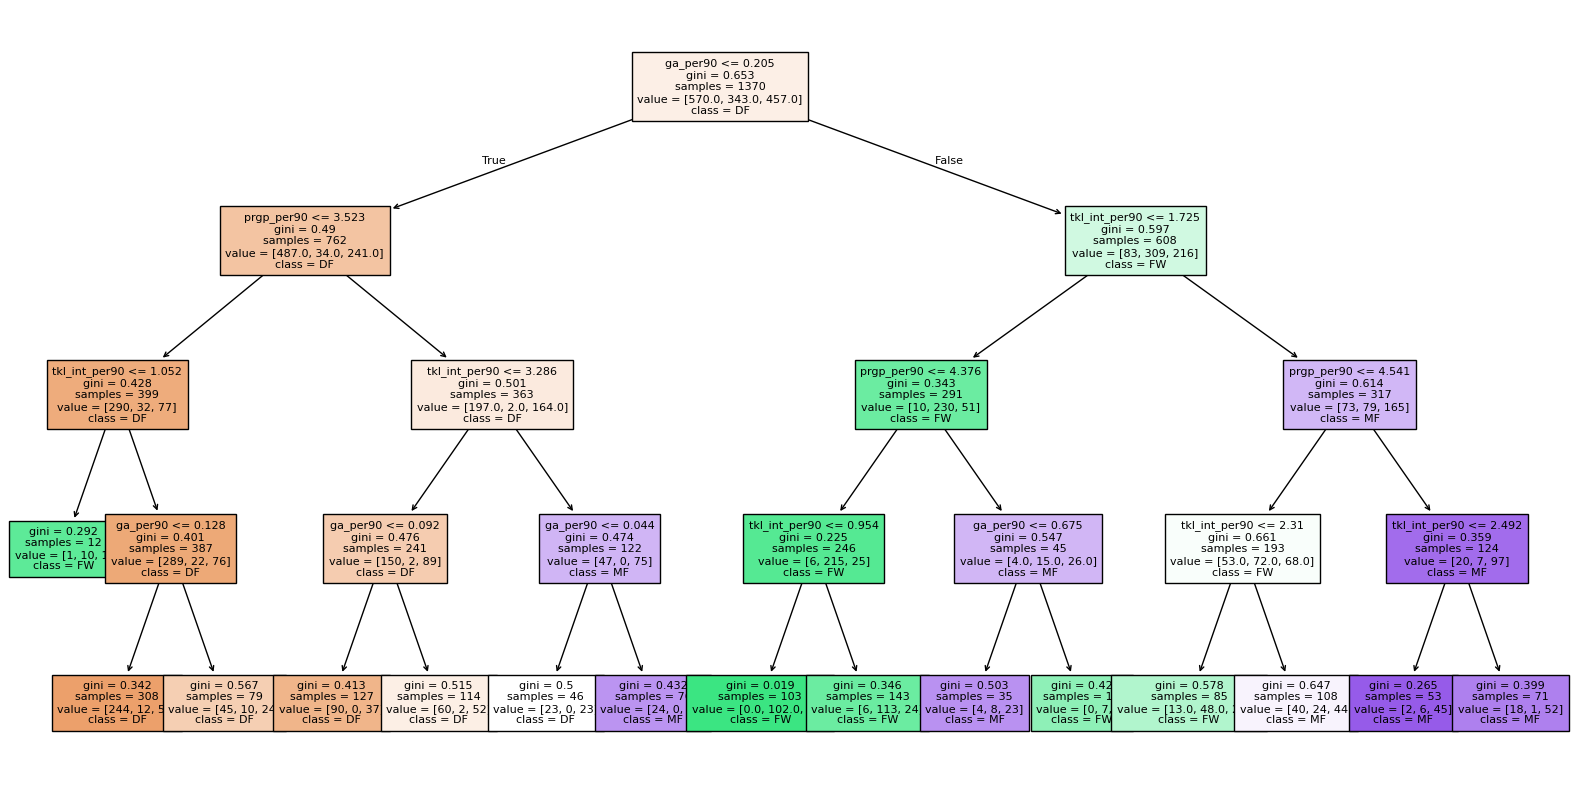

|--- ga_per90 <= 0.21
|   |--- prgp_per90 <= 3.52
|   |   |--- tkl_int_per90 <= 1.05
|   |   |   |--- class: FW
|   |   |--- tkl_int_per90 >  1.05
|   |   |   |--- ga_per90 <= 0.13
|   |   |   |   |--- class: DF
|   |   |   |--- ga_per90 >  0.13
|   |   |   |   |--- class: DF
|   |--- prgp_per90 >  3.52
|   |   |--- tkl_int_per90 <= 3.29
|   |   |   |--- ga_per90 <= 0.09
|   |   |   |   |--- class: DF
|   |   |   |--- ga_per90 >  0.09
|   |   |   |   |--- class: DF
|   |   |--- tkl_int_per90 >  3.29
|   |   |   |--- ga_per90 <= 0.04
|   |   |   |   |--- class: DF
|   |   |   |--- ga_per90 >  0.04
|   |   |   |   |--- class: MF
|--- ga_per90 >  0.21
|   |--- tkl_int_per90 <= 1.72
|   |   |--- prgp_per90 <= 4.38
|   |   |   |--- tkl_int_per90 <= 0.95
|   |   |   |   |--- class: FW
|   |   |   |--- tkl_int_per90 >  0.95
|   |   |   |   |--- class: FW
|   |   |--- prgp_per90 >  4.38
|   |   |   |--- ga_per90 <= 0.68
|   |   |   |   |--- class: MF
|   |   |   |--- ga_per90 >  0.68
|   |   |

In [16]:
X = data[H1_FEATURES]
y = data["position"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=RANDOM_STATE, stratify=y
)

tree_classifier = DecisionTreeClassifier(
    max_depth=4,
    min_samples_leaf=10,
    random_state=RANDOM_STATE
)

tree_classifier.fit(X_train, y_train)
pred = tree_classifier.predict(X_test)

print("Accuracy:", round(accuracy_score(y_test, pred), 3))
print(classification_report(y_test, pred))

ConfusionMatrixDisplay.from_predictions(y_test, pred)
plt.title("Macierz klasyfikacji - drzewo")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "drzewo_macierz_klasyfikacji.png", dpi=150)
plt.show()

plt.figure(figsize=(16, 8))
plot_tree(
    tree_classifier,
    feature_names=H1_FEATURES,
    class_names=tree_classifier.classes_,
    filled=True,
    fontsize=8
)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "drzewo_klasyfikacyjne.png", dpi=150)
plt.show()

print(export_text(tree_classifier, feature_names=H1_FEATURES))

{'model': 'H2', 'R2': 0.7426634301721962, 'MAE': 0.05633276672613303, 'MSE': 0.006637976725756028}
|--- xg_per90 <= 0.26
|   |--- xg_per90 <= 0.11
|   |   |--- sot_per90 <= 0.20
|   |   |   |--- xg_per90 <= 0.03
|   |   |   |   |--- value: [0.01]
|   |   |   |--- xg_per90 >  0.03
|   |   |   |   |--- value: [0.04]
|   |   |--- sot_per90 >  0.20
|   |   |   |--- xg_per90 <= 0.06
|   |   |   |   |--- value: [0.06]
|   |   |   |--- xg_per90 >  0.06
|   |   |   |   |--- value: [0.09]
|   |--- xg_per90 >  0.11
|   |   |--- sot_per90 <= 0.76
|   |   |   |--- xg_per90 <= 0.19
|   |   |   |   |--- value: [0.14]
|   |   |   |--- xg_per90 >  0.19
|   |   |   |   |--- value: [0.20]
|   |   |--- sot_per90 >  0.76
|   |   |   |--- sot_per90 <= 0.97
|   |   |   |   |--- value: [0.26]
|   |   |   |--- sot_per90 >  0.97
|   |   |   |   |--- value: [0.21]
|--- xg_per90 >  0.26
|   |--- xg_per90 <= 0.55
|   |   |--- xg_per90 <= 0.40
|   |   |   |--- sot_per90 <= 0.85
|   |   |   |   |--- value: [0.28]
|

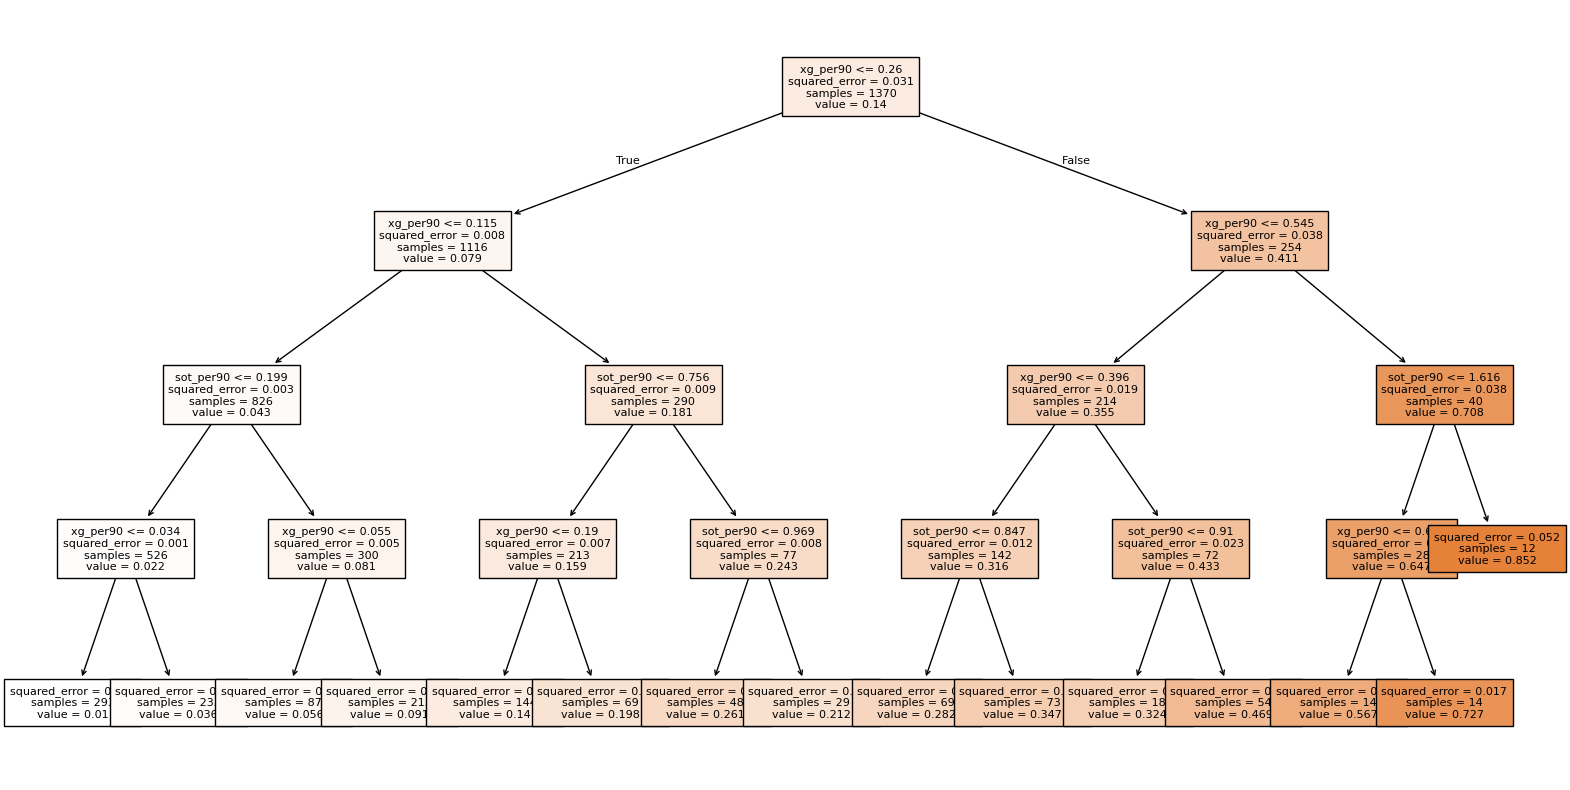

{'model': 'H3', 'R2': 0.6351990158604218, 'MAE': 0.8070242624877089, 'MSE': 1.0900918505046195}
|--- carries_per90 <= 31.05
|   |--- touches_per90 <= 40.44
|   |   |--- carries_per90 <= 17.26
|   |   |   |--- touches_per90 <= 25.65
|   |   |   |   |--- value: [0.97]
|   |   |   |--- touches_per90 >  25.65
|   |   |   |   |--- value: [1.48]
|   |   |--- carries_per90 >  17.26
|   |   |   |--- touches_per90 <= 36.71
|   |   |   |   |--- value: [1.95]
|   |   |   |--- touches_per90 >  36.71
|   |   |   |   |--- value: [2.32]
|   |--- touches_per90 >  40.44
|   |   |--- kp_per90 <= 0.39
|   |   |   |--- kp_per90 <= 0.11
|   |   |   |   |--- value: [1.90]
|   |   |   |--- kp_per90 >  0.11
|   |   |   |   |--- value: [2.83]
|   |   |--- kp_per90 >  0.39
|   |   |   |--- carries_per90 <= 23.38
|   |   |   |   |--- value: [2.86]
|   |   |   |--- carries_per90 >  23.38
|   |   |   |   |--- value: [3.59]
|--- carries_per90 >  31.05
|   |--- kp_per90 <= 0.43
|   |   |--- touches_per90 <= 78.12
| 

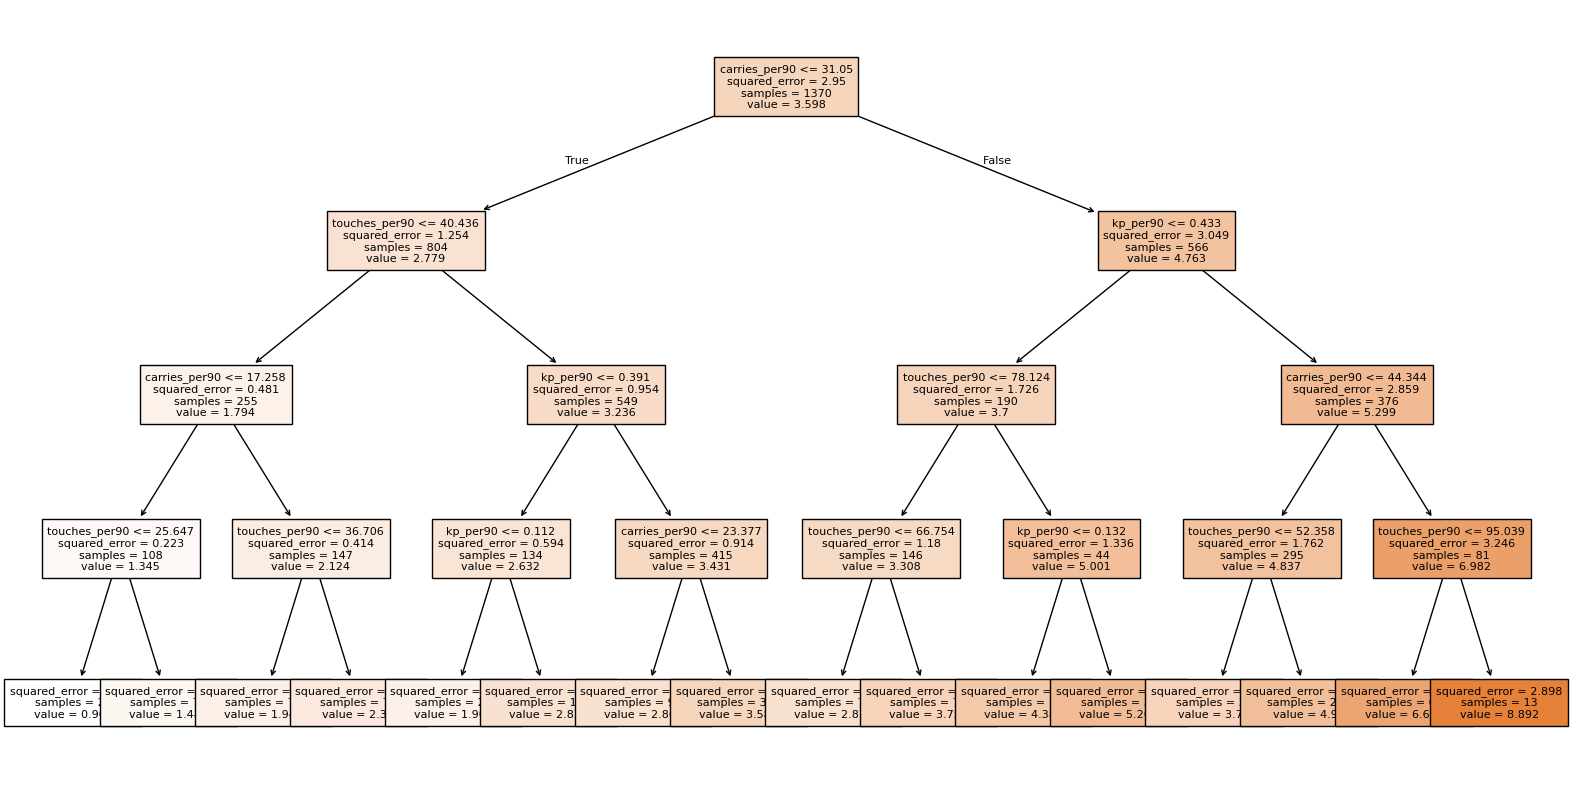

In [17]:
def regression_tree(target, features, name):
    X = data[features]
    y = data[target]

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.25, random_state=RANDOM_STATE
    )

    model = DecisionTreeRegressor(
        max_depth=4,
        min_samples_leaf=10,
        random_state=RANDOM_STATE
    )

    model.fit(X_train, y_train)
    pred = model.predict(X_test)

    results = {
        "model": name,
        "R2": r2_score(y_test, pred),
        "MAE": mean_absolute_error(y_test, pred),
        "MSE": mean_squared_error(y_test, pred)
    }

    print(results)
    print(export_text(model, feature_names=features))

    plt.figure(figsize=(16, 8))
    plot_tree(model, feature_names=features, filled=True, fontsize=8)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / f"drzewo_regresyjne_{name}.png", dpi=150)
    plt.show()

    return results

tree_h2 = regression_tree(H2_TARGET, H2_FEATURES, "H2")
tree_h3 = regression_tree(H3_TARGET, H3_FEATURES, "H3")

pd.DataFrame([tree_h2, tree_h3]).to_csv(
    OUTPUT_DIR / "drzewa_regresyjne_wyniki.csv", index=False
)

## Analiza skupień - k-średnich

In [18]:
CLUSTER_FEATURES = [
    "tkl_int_per90", "ga_per90", "prgp_per90",
    "gls_per90", "xg_per90", "touches_per90",
    "kp_per90", "carries_per90"
]

X_cluster = StandardScaler().fit_transform(data[CLUSTER_FEATURES])

kf = KFold(n_splits=10, shuffle=True, random_state=RANDOM_STATE)
rows = []

for k in range(2, 7):
    scores = []

    for train_idx, test_idx in kf.split(X_cluster):
        model = KMeans(
            n_clusters=k,
            random_state=RANDOM_STATE,
            n_init=3,
            max_iter=100
        )

        model.fit(X_cluster[train_idx])
        labels = model.predict(X_cluster[test_idx])

        if len(np.unique(labels)) > 1:
            scores.append(silhouette_score(X_cluster[test_idx], labels))

    rows.append({
        "liczba_klastrow": k,
        "sredni_silhouette": np.mean(scores)
    })

kmeans_cv = pd.DataFrame(rows)
display(kmeans_cv.round(4))

best_k = int(kmeans_cv.loc[kmeans_cv["sredni_silhouette"].idxmax(), "liczba_klastrow"])
print("Wybrana liczba klastrów:", best_k)

kmeans = KMeans(
    n_clusters=best_k,
    random_state=RANDOM_STATE,
    n_init=5,
    max_iter=150
)

data["cluster_kmeans"] = kmeans.fit_predict(X_cluster)

kmeans_profiles = data.groupby("cluster_kmeans")[CLUSTER_FEATURES].mean()
kmeans_positions = pd.crosstab(
    data["cluster_kmeans"], data["position"], normalize="index"
).round(3)

display(kmeans_profiles.round(3))
display(kmeans_positions)

kmeans_cv.to_csv(OUTPUT_DIR / "kmeans_cv.csv", index=False)
kmeans_profiles.to_csv(OUTPUT_DIR / "kmeans_profile.csv")
kmeans_positions.to_csv(OUTPUT_DIR / "kmeans_pozycje.csv")

,liczba_klastrow,sredni_silhouette
0,2,0.3544
1,3,0.2786
2,4,0.2522
3,5,0.2415
4,6,0.2044


Wybrana liczba klastrów: 2


,tkl_int_per90,ga_per90,prgp_per90,gls_per90,xg_per90,touches_per90,kp_per90,carries_per90
cluster_kmeans,,,,,,,,
0,2.913,0.121,3.975,0.054,0.063,62.042,0.759,33.756
1,1.453,0.483,2.827,0.323,0.318,40.972,1.327,23.981


position,DF,FW,MF
cluster_kmeans,,,
0,0.594,0.036,0.371
1,0.020,0.730,0.250


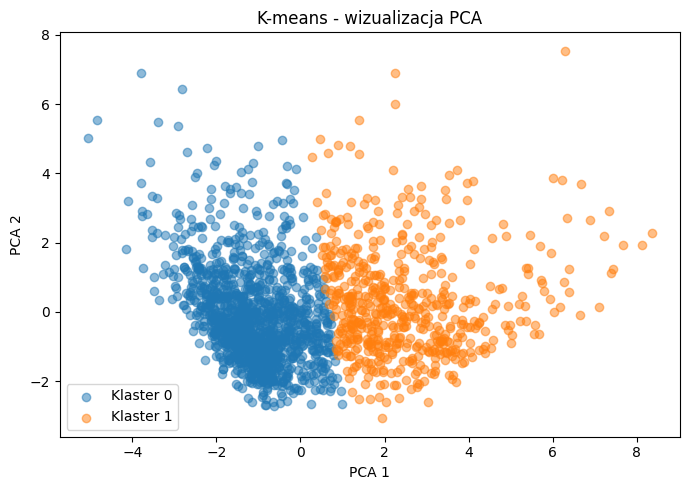

In [19]:
pca = PCA(n_components=2)
pca_values = pca.fit_transform(X_cluster)

plt.figure(figsize=(7, 5))
for cluster in sorted(data["cluster_kmeans"].unique()):
    mask = data["cluster_kmeans"] == cluster
    plt.scatter(
        pca_values[mask, 0],
        pca_values[mask, 1],
        alpha=0.5,
        label=f"Klaster {cluster}"
    )

plt.title("K-means - wizualizacja PCA")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "kmeans_pca.png", dpi=150)
plt.show()

## Analiza skupień - EM

In [20]:
em_rows = []

for n_components in range(2, 7):
    model = GaussianMixture(
        n_components=n_components,
        random_state=RANDOM_STATE
    )
    model.fit(X_cluster)

    em_rows.append({
        "liczba_klastrow": n_components,
        "BIC": model.bic(X_cluster),
        "AIC": model.aic(X_cluster)
    })

em_scores = pd.DataFrame(em_rows)
display(em_scores.round(2))

best_em = int(em_scores.loc[em_scores["BIC"].idxmin(), "liczba_klastrow"])
print("Wybrana liczba klastrów EM:", best_em)

em = GaussianMixture(n_components=best_em, random_state=RANDOM_STATE)
data["cluster_em"] = em.fit_predict(X_cluster)

em_profiles = data.groupby("cluster_em")[CLUSTER_FEATURES].mean()
em_positions = pd.crosstab(
    data["cluster_em"], data["position"], normalize="index"
).round(3)

display(em_profiles.round(3))
display(em_positions)

em_scores.to_csv(OUTPUT_DIR / "em_bic_aic.csv", index=False)
em_profiles.to_csv(OUTPUT_DIR / "em_profile.csv")
em_positions.to_csv(OUTPUT_DIR / "em_pozycje.csv")

,liczba_klastrow,BIC,AIC
0,2,24169.20,23678.77
1,3,23163.72,22425.32
2,4,23019.26,22032.89
3,5,19159.54,17925.20
4,6,19190.67,17708.37


Wybrana liczba klastrów EM: 5


,tkl_int_per90,ga_per90,prgp_per90,gls_per90,xg_per90,touches_per90,kp_per90,carries_per90
cluster_em,,,,,,,,
0,2.611,0.310,4.789,0.141,0.137,61.156,1.506,34.158
1,1.313,0.374,2.018,0.261,0.278,35.744,1.027,20.554
2,3.103,0.112,3.755,0.033,0.046,61.291,0.640,32.592
3,1.366,0.717,3.653,0.474,0.454,45.102,1.639,28.183
4,2.868,0.043,3.567,0.043,0.049,61.753,0.452,33.582


position,DF,FW,MF
cluster_em,,,
0,0.284,0.168,0.548
1,0.012,0.810,0.177
2,0.655,0.005,0.340
3,0.000,0.731,0.269
4,0.705,0.024,0.271


## Dodatkowy algorytm - Random Forest

Accuracy: 0.803
              precision    recall  f1-score   support

          DF       0.86      0.86      0.86       191
          FW       0.83      0.84      0.84       114
          MF       0.71      0.70      0.71       152

    accuracy                           0.80       457
   macro avg       0.80      0.80      0.80       457
weighted avg       0.80      0.80      0.80       457



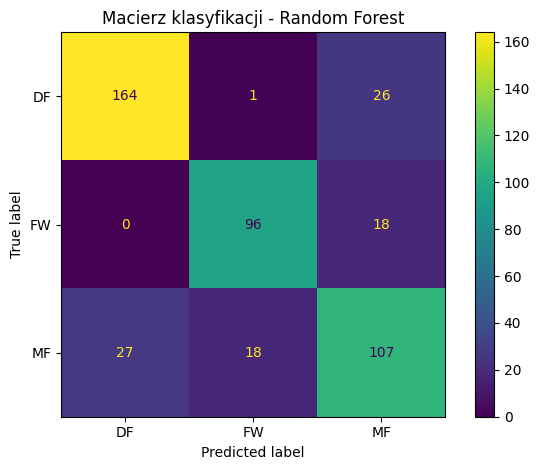

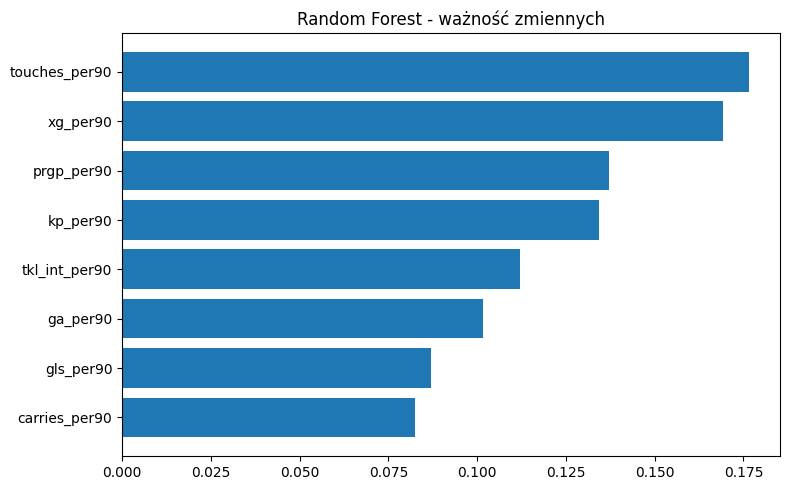

In [21]:
X = data[CLUSTER_FEATURES]
y = data["position"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=RANDOM_STATE, stratify=y
)

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=RANDOM_STATE
)

rf.fit(X_train, y_train)
pred = rf.predict(X_test)

print("Accuracy:", round(accuracy_score(y_test, pred), 3))
print(classification_report(y_test, pred))

ConfusionMatrixDisplay.from_predictions(y_test, pred)
plt.title("Macierz klasyfikacji - Random Forest")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "rf_macierz_klasyfikacji.png", dpi=150)
plt.show()

importance = pd.Series(
    rf.feature_importances_,
    index=CLUSTER_FEATURES
).sort_values()

importance.to_csv(OUTPUT_DIR / "rf_waznosc.csv")

plt.figure(figsize=(8, 5))
plt.barh(importance.index, importance.values)
plt.title("Random Forest - ważność zmiennych")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "rf_waznosc.png", dpi=150)
plt.show()